<a href="https://colab.research.google.com/github/alokchoudharyguliya/Transformers/blob/llm-mistral/LLM_Mistral_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mistral_common

In [9]:
import torch
import os
from mistral_common.tokens.tokenizers.mistral import MistralTokenizer

In [10]:
cd /content/drive/MyDrive/mistral-inference

/content/drive/MyDrive/mistral-inference


In [11]:
!wget https://models.mistralcdn.com/mistral-7b-v0-3/mistral-7B-Instruct-v0.3.tar

--2026-03-21 06:55:50--  https://models.mistralcdn.com/mistral-7b-v0-3/mistral-7B-Instruct-v0.3.tar
Resolving models.mistralcdn.com (models.mistralcdn.com)... 172.67.70.68, 104.26.6.117, 104.26.7.117, ...
Connecting to models.mistralcdn.com (models.mistralcdn.com)|172.67.70.68|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14496675840 (14G) [application/x-tar]
Saving to: ‘mistral-7B-Instruct-v0.3.tar.1’

mistral-7B-Instruct 100%[===================>]  13.50G  14.7MB/s    in 7m 11s  

2026-03-21 07:03:02 (32.1 MB/s) - ‘mistral-7B-Instruct-v0.3.tar.1’ saved [14496675840/14496675840]



In [16]:
!tar -xvf '/content/drive/MyDrive/mistral-inference/mistral-7B-Instruct-v0.3.tar.1' -C './weights'

consolidated.safetensors
params.json
tokenizer.model.v3


In [18]:
mistral_tokenizer=MistralTokenizer.from_file("./weights/tokenizer.model.v3")
tokenizer=mistral_tokenizer.instruct_tokenizer.tokenizer

In [19]:
prompts=[
    'Who is the best tennis player of all time',
    'Describer in a few words, why transformers are so powerful in AI'
]

In [21]:
encoded_prompts=[tokenizer.encode(prompt,bos=True,eos=False) for prompt in prompts]

In [ ]:
encoded_prompts

In [22]:
def pre_computed_thetas(dim:int, end:int,theta:float=1000.0):
  freqs=1.0/(theta**(torch.arange(0,dim,2)[:dim//2].float()/dim))

In [25]:
def pre_compute_thetas(dim,end):
  thetas=1.0/(10000.0**(torch.arange(0,dim,2)[:dim//2].float()/dim))
  print(thetas)

In [26]:
pre_compute_thetas(8,8)

tensor([1.0000, 0.1000, 0.0100, 0.0010])


mtheta----> cost(mtheta)+i sin(mtheta)

In [27]:
def apply_rotary_embed(x,cosin_m_thetas):
  # x is (bs,seqlen,n_heads,head_dim) -> (1,2,4,8)
  # cosin_m_thetas is (seq_len, head_dim/2,2) eg -> (2,4,2)
  # dimension change from say 8 -----> (4,2)

SyntaxError: incomplete input (3901944604.py, line 3)

In [ ]:
apply_rotary_embed(torch.randn(1,2,1,8),cosin_m_thetas )

Grouped Query Attention -  https://arxiv.org/pdf/2305.13245
- a balance between the Multi Head Attention and the Multi Query Attention


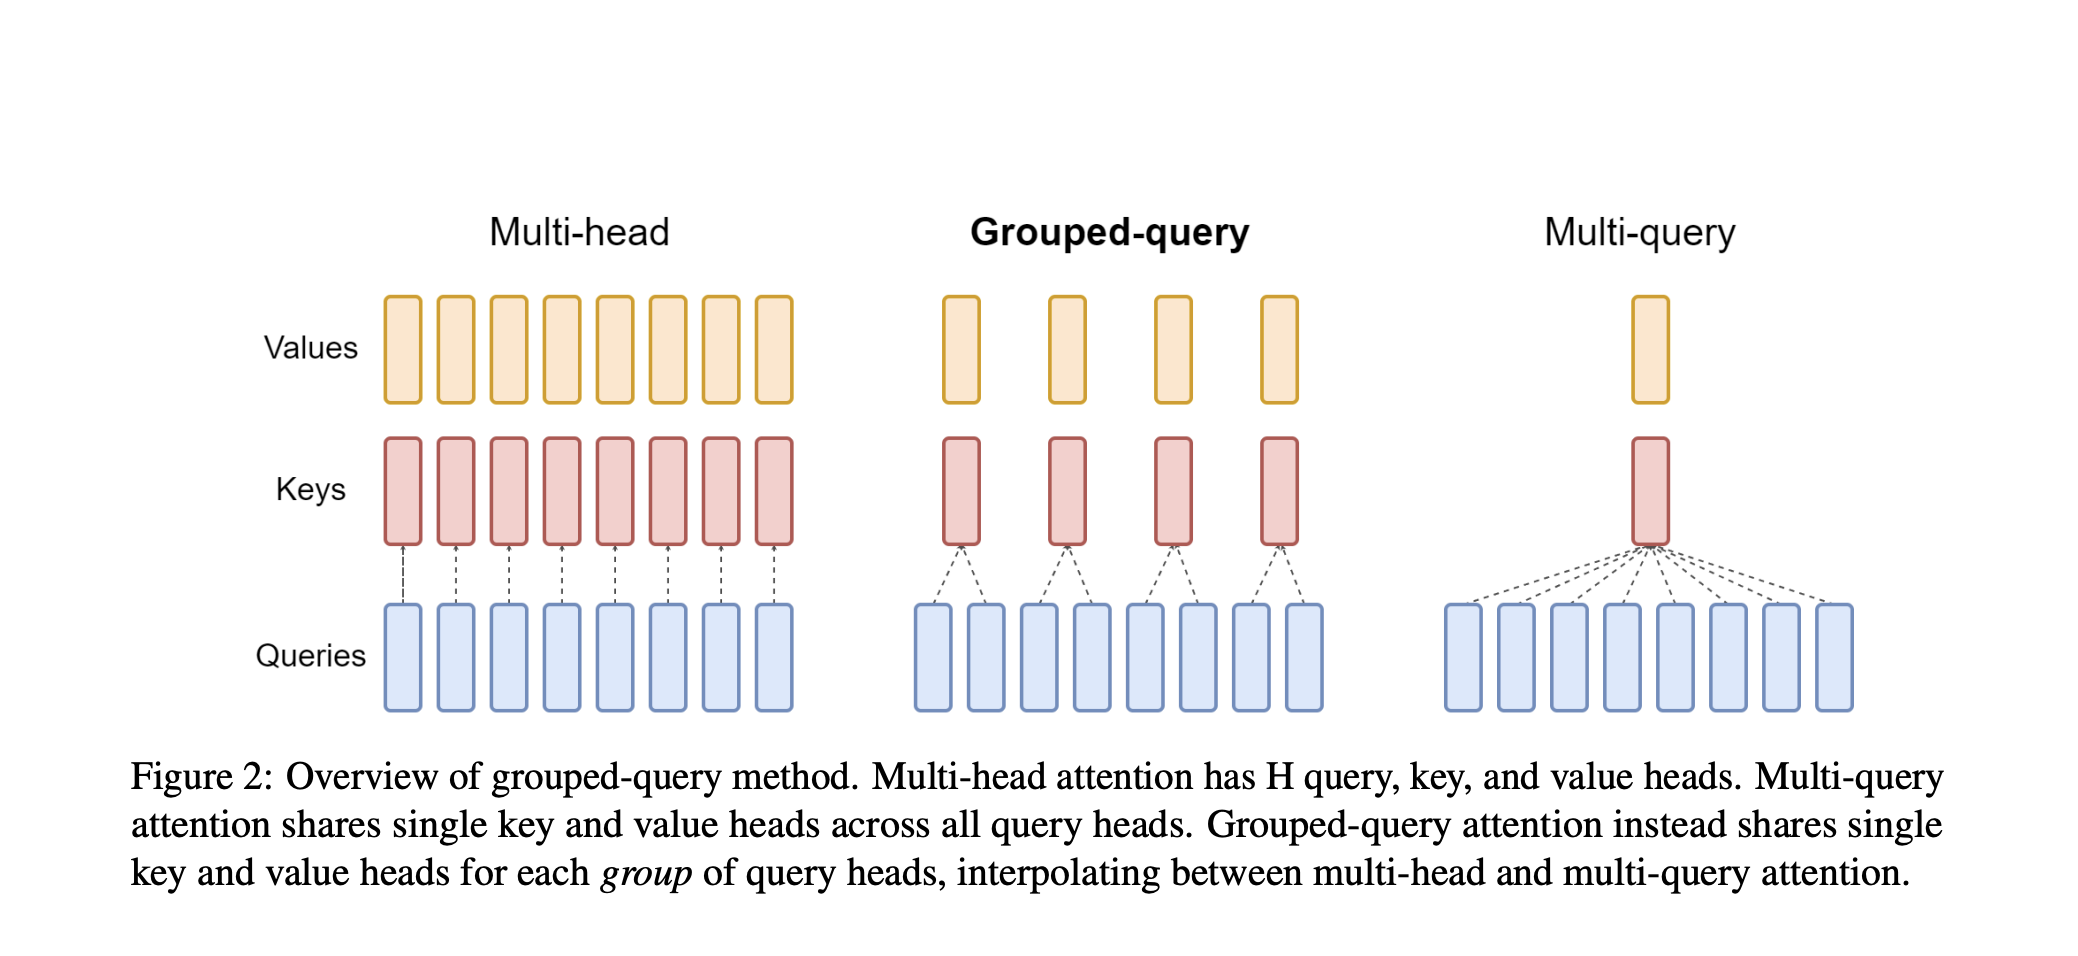

Sliding Window Attention VS Vanila Attention
- says that with using the window also we will eventually capture the entire context of the sentence

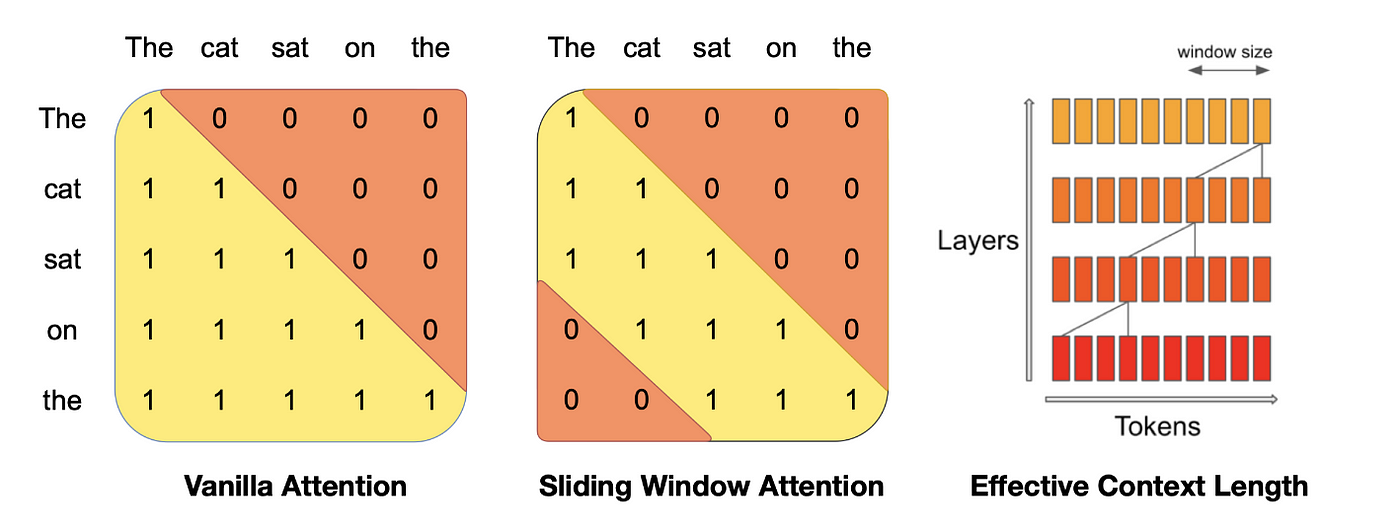

In [28]:
from dataclasses import dataclass
@dataclass
class TransformerArgs(Serializable):
  dim:int =4096
  n_layers:int = 32
  head_dim:int=128
  hidden_dim:int = 14336
  n_heads:int =32
  n_kv_heads:int=8
  norm_epochs:float=1e-05
  vocab_size:int=32768
  rope_n:Optional[float]=1000000.0
  max_seq_len:int=16384
  max_batch_size:int=1

NameError: name 'Serializable' is not defined

In [29]:
args=TransformerArggs()

NameError: name 'TransformerArggs' is not defined

In [ ]:
def percompute_thetas(dim,end,rope_n):
  thetas=1.0/(rope_n**(torch.arange(0,dim,2)[:dim//2]).float()/dim)
  m_thetas=torch.outer(torch.arange(0,end),thetas)
  complexthetas=torch.polar(torch.ones_like(m_thetas),m_thetas)
  cosin_m_thetas=torch.stack([complexthetas.real,complexthetas.imag],dim=-1)
  return

In [ ]:
class AttentionArgs(nn.Module):
  def __init__(self,args:TransformerArgs):
    super().__init__()
    self.args=args

    self.n_heads:int = args.n_heads
    self.n_kv_heads:int =args.n_kv_heads
    self.repeats=self.n_heads//self.n_kv_heads
    self.scale=self.args.head_dim**0.5
    self.wq=nn.Linear(args.dim,args.n_heads*args.head_dim,bias=False)

    self.wo=nn.Linear()

    self.cache_k=torch.empty(

    )
    self.cache_v=torch.empty(

    )
